# M6 · RecSys Landscape — Hands-on Notebook

**Companion to curriculum lesson M6.** Runnable, visual examples of every family M6
discusses — **collaborative filtering** (user-user & item-item), **matrix
factorization / latent factors**, **two-tower retrieval + ANN**, **sequential**, and
**generative retrieval** — plus the **retrieval→ranking funnel** and cold-start.

Runs top-to-bottom in Google Colab with **no installs** (pandas, numpy,
scikit-learn, matplotlib only). Each example's markdown explains **why** it's built
that way, not just what the code does.

- **Basic (10):** interaction matrix & sparsity · popularity baseline · user-user CF ·
  item-item CF · the cosine-similarity idea · cold-start failure · matrix
  factorization (SGD) · latent-factor map · MF reconstruction · MF top-k recs
- **Easy (5):** train/test recall@k · CF vs MF vs popularity bake-off · the
  retrieval→ranking funnel · implicit feedback + negative sampling · two-tower model
- **Advanced (5):** ANN vs brute force (recall/latency) · sequential (order matters) ·
  generative retrieval (semantic IDs) · full funnel bake-off · cold-start fixed with content

## Setup — a synthetic dataset *with real latent structure*

CF and MF only "work" when the data has hidden structure to recover, so we build it in:
**200 members**, **120 items**, **5 genres**. Each member prefers 1–2 genres; each item
belongs to a genre and has a popularity drawn from a **power law** (a few hits, a long
tail). A member interacts with items in proportion to *(their genre affinity × item
popularity)*. That mirrors reality — taste + popularity — and means a good model can
recover genre clusters, while popularity alone is a real baseline to beat.

In [1]:
import numpy as np, pandas as pd, time
import matplotlib.pyplot as plt
plt.rcParams.update({"axes.grid": True, "grid.alpha": .3, "figure.autolayout": True})
BLUE, GREEN, RED, PURPLE, GOLD, GRAY = "#4C72B0", "#55A868", "#C44E52", "#8172B3", "#CCB974", "#888"

rng = np.random.default_rng(42)
n_users, n_items, n_genres = 200, 120, 5
genres = ["tech", "cooking", "fitness", "travel", "finance"]
item_genre = rng.integers(0, n_genres, n_items)
item_pop = (rng.zipf(1.3, n_items) * 1.0).clip(max=20)          # power-law popularity (tamed)

# each user prefers 1-2 genres (this is the latent taste we hope to recover)
user_pref = np.full((n_users, n_genres), 0.05)
for u in range(n_users):
    favs = rng.choice(n_genres, size=rng.integers(1, 3), replace=False)
    user_pref[u, favs] += 2.0
user_pref /= user_pref.sum(1, keepdims=True)

# generate implicit interactions: prob(item) ~ genre affinity x item popularity
R = np.zeros((n_users, n_items), dtype=int)
for u in range(n_users):
    p = user_pref[u, item_genre] * item_pop
    p /= p.sum()
    k = rng.integers(8, 25)
    items = rng.choice(n_items, size=k, replace=False, p=p)
    R[u, items] = 1

interactions = R.sum()
sparsity = 1 - interactions / R.size
print(f"interactions: {interactions}  |  matrix {R.shape}  |  sparsity {sparsity:.1%}")
print("avg interactions/user:", round(R.sum(1).mean(), 1))

interactions: 3245  |  matrix (200, 120)  |  sparsity 86.5%
avg interactions/user: 16.2


---
# Basic (10) — the interaction matrix, CF, and MF

## 1 · The user–item interaction matrix (and why it's mostly empty)

**Why:** every classic recommender starts from one object — a matrix `R` where
`R[u,i]=1` if member `u` interacted with item `i`. Visualizing it shows the central
challenge: it's **overwhelmingly zeros** (sparse), so most user–item opinions are
*unknown*, not *negative*. The whole game is filling in those blanks.

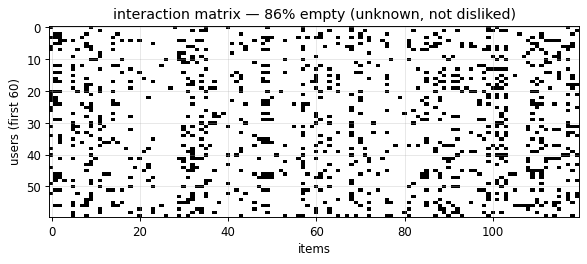

In [2]:
plt.figure(figsize=(7,3.2))
plt.imshow(R[:60, :120], aspect="auto", cmap="Greys", interpolation="nearest")
plt.xlabel("items"); plt.ylabel("users (first 60)")
plt.title(f"interaction matrix — {sparsity:.0%} empty (unknown, not disliked)")
plt.tight_layout(); plt.show()

## 2 · Popularity baseline — the bar every model must clear

**Why:** before anything clever, rank items by how often they're consumed. It ignores
personalization, but it's shockingly hard to beat on head items, so it's the honest
baseline. If your fancy model can't beat popularity on held-out recall, it isn't
learning taste.

top-10 popular items: [11, 9, 32, 5, 109, 8, 57, 68, 102, 99]


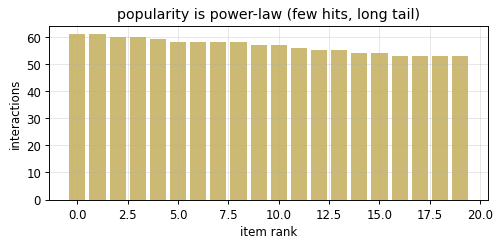

In [3]:
pop_score = R.sum(0)                       # column sums = item popularity
top_pop = np.argsort(-pop_score)[:10]
print("top-10 popular items:", top_pop.tolist())

plt.figure(figsize=(6,3))
plt.bar(range(20), np.sort(pop_score)[::-1][:20], color=GOLD)
plt.xlabel("item rank"); plt.ylabel("interactions"); plt.title("popularity is power-law (few hits, long tail)")
plt.tight_layout(); plt.show()

## 3 · User–user collaborative filtering — "people like you also liked…"

**Why:** the CF hypothesis is that **similar users like similar things**. We measure
similarity between users by the **cosine** of their interaction rows (angle between the
two 0/1 vectors — high when they overlap a lot, independent of how active each is).
Then to score an item for user `u`, we take a **similarity-weighted vote** of who else
interacted with it. Cosine (not raw overlap) is used so a hyper-active user doesn't
dominate every neighborhood.

user 0 fav genres: ['tech']
user-user CF recommends items: [103, 32, 119, 111, 110] | their genres: ['tech', 'tech', 'tech', 'travel', 'cooking']


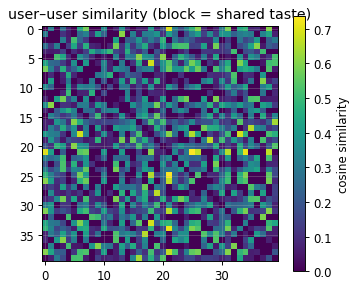

In [4]:
from sklearn.metrics.pairwise import cosine_similarity

user_sim = cosine_similarity(R)            # 200x200, cosine of interaction rows
np.fill_diagonal(user_sim, 0)              # a user is not their own neighbor

u = 0
scores = user_sim[u] @ R                    # weighted vote: sum_v sim(u,v) * R[v,i]
scores[R[u] == 1] = -np.inf                 # don't re-recommend seen items
recs = np.argsort(-scores)[:5]
print("user 0 fav genres:", [genres[g] for g in np.where(user_pref[0] > 0.2)[0]])
print("user-user CF recommends items:", recs.tolist(),
      "| their genres:", [genres[item_genre[i]] for i in recs])

plt.figure(figsize=(4.2,3.6))
plt.imshow(user_sim[:40, :40], cmap="viridis"); plt.colorbar(label="cosine similarity")
plt.title("user–user similarity (block = shared taste)"); plt.tight_layout(); plt.show()

## 4 · Item–item collaborative filtering — the score formula, by hand

**Why:** item-item CF is what production CF usually means (item neighborhoods are more
stable than user ones and can be precomputed). The lesson's formula
$\text{score}(u,i)=\sum_{j\in I(u)} \text{sim}(i,j)\,r_{u,j}$ says: *an item is a good
rec if it's similar to items the user already liked.* We compute item–item cosine, then
score exactly by that sum.

In [5]:
item_sim = cosine_similarity(R.T)          # 120x120 item-item cosine
np.fill_diagonal(item_sim, 0)

u = 0
liked = np.where(R[u] == 1)[0]             # I(u): items the user interacted with
score_i = item_sim[:, liked].sum(1)        # sum_j sim(i,j) for j in I(u)  (r_{u,j}=1)
score_i[R[u] == 1] = -np.inf
recs = np.argsort(-score_i)[:5]
print("user 0 liked genres:", [genres[item_genre[j]] for j in liked][:6], "...")
print("item-item CF recommends:", recs.tolist(),
      "| genres:", [genres[item_genre[i]] for i in recs])

user 0 liked genres: ['tech', 'tech', 'fitness', 'tech', 'tech', 'travel'] ...
item-item CF recommends: [103, 32, 119, 44, 82] | genres: ['tech', 'tech', 'tech', 'tech', 'tech']


## 5 · What "cosine similarity" actually measures

**Why:** similarity is the whole engine of CF, so it's worth *seeing*. Two users who
like the same items point in nearly the **same direction** (small angle → cosine ≈ 1);
two with disjoint tastes are near-orthogonal (cosine ≈ 0). We show three 2-D vectors to
make the angle-not-magnitude idea concrete.

cos(a,b)=1.00 (similar taste)   cos(a,c)=0.86 (different)


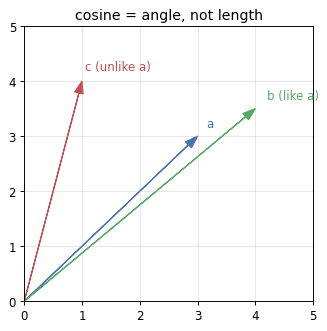

In [6]:
a = np.array([3., 3.]); b = np.array([4., 3.5]); c = np.array([1., 4.])
def cos(x, y): return x @ y / (np.linalg.norm(x)*np.linalg.norm(y))
print(f"cos(a,b)={cos(a,b):.2f} (similar taste)   cos(a,c)={cos(a,c):.2f} (different)")

plt.figure(figsize=(4,4))
for v, col, name in [(a,BLUE,"a"),(b,GREEN,"b (like a)"),(c,RED,"c (unlike a)")]:
    plt.arrow(0,0,v[0],v[1],head_width=0.15,color=col,length_includes_head=True)
    plt.text(v[0]*1.05, v[1]*1.05, name, color=col)
plt.xlim(0,5); plt.ylim(0,5); plt.title("cosine = angle, not length"); plt.tight_layout(); plt.show()

## 6 · Cold-start — why CF is blind to a brand-new item

**Why:** the failure mode you must be able to name. A newly launched item is an
**all-zero column** in `R` — nobody has interacted with it yet — so it has *no*
neighbors and *zero* similarity to anything. CF literally cannot recommend it. We insert
a new item and watch its similarity be zero to every other item.

In [7]:
R_cold = np.hstack([R, np.zeros((n_users, 1), dtype=int)])   # append an all-zero new item
new_id = R_cold.shape[1] - 1
sims_to_new = cosine_similarity(R_cold.T)[new_id]
print(f"new item {new_id}: interactions={R_cold[:,new_id].sum()}, "
      f"max similarity to any item={np.nan_to_num(sims_to_new).max():.3f}")
print("=> CF gives it a score of 0 everywhere. Needs content features (example 20).")

new item 120: interactions=0, max similarity to any item=0.000
=> CF gives it a score of 0 everywhere. Needs content features (example 20).


## 7 · Matrix factorization — learn latent factors with SGD

**Why:** CF only compares *observed* overlaps. MF instead compresses the matrix into a
small vector per user (`P[u]`) and per item (`Q[i]`) so that
$\hat r_{u,i}=P_u\!\cdot\!Q_i$. The coordinates are **latent factors** — learned taste
dimensions (roughly genre here). We train them by gradient descent on the observed
entries plus sampled negatives, so the dot product is high for real interactions and low
otherwise. This *generalizes past exact neighbors*: a user near a genre cluster scores
all items in it, even ones no similar user touched.

final BPR loss: 0.145


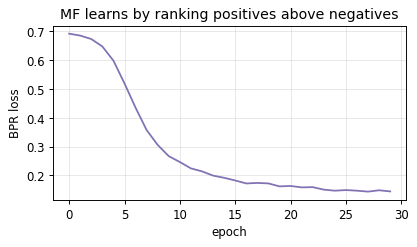

In [8]:
K = 16                                       # latent dimension
P = rng.normal(0, 0.1, (n_users, K))
Q = rng.normal(0, 0.1, (n_items, K))
pos = np.argwhere(R == 1)                     # observed (user,item) pairs
lr, reg, epochs = 0.05, 0.02, 30
losses = []
for ep in range(epochs):
    rng.shuffle(pos)
    tot = 0.0
    for u, i in pos:
        j = rng.integers(n_items)             # a random negative item
        while R[u, j] == 1: j = rng.integers(n_items)
        # BPR: want score(u,i) > score(u,j)
        diff = P[u] @ (Q[i] - Q[j])
        sig = 1/(1+np.exp(diff))              # gradient weight
        P[u] += lr*(sig*(Q[i]-Q[j]) - reg*P[u])
        Q[i] += lr*(sig*P[u] - reg*Q[i])
        Q[j] += lr*(-sig*P[u] - reg*Q[j])
        tot += -np.log(1/(1+np.exp(-diff)))
    losses.append(tot/len(pos))
print("final BPR loss:", round(losses[-1], 3))
plt.figure(figsize=(5,3)); plt.plot(losses, color=PURPLE)
plt.xlabel("epoch"); plt.ylabel("BPR loss"); plt.title("MF learns by ranking positives above negatives"); plt.tight_layout(); plt.show()

## 8 · The latent-factor map — do items self-organize by taste?

**Why:** the payoff of MF is that its learned item vectors should cluster by hidden
taste **without ever being told the genres**. We compress the 16-D item vectors to 2-D
(PCA) and color by true genre. Clean color clusters = MF recovered the structure.

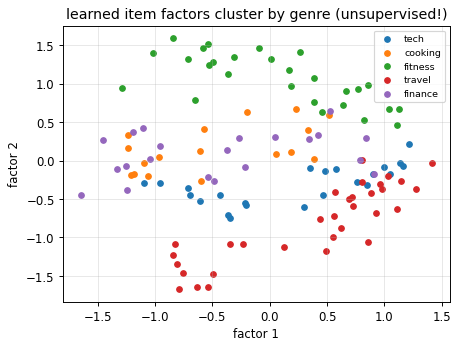

In [9]:
from sklearn.decomposition import PCA
Q2 = PCA(2).fit_transform(Q)
plt.figure(figsize=(5.5,4.2))
for g in range(n_genres):
    m = item_genre == g
    plt.scatter(Q2[m,0], Q2[m,1], s=22, label=genres[g])
plt.legend(fontsize=8); plt.title("learned item factors cluster by genre (unsupervised!)")
plt.xlabel("factor 1"); plt.ylabel("factor 2"); plt.tight_layout(); plt.show()

## 9 · MF reconstruction — measurably personalized (not just popular)

**Why:** the real test of MF is whether it recommends *your* taste, not just globally
popular items. We measure, across **all** users, what fraction of each user's MF top-10
falls in their single **favorite** genre, and compare to the popularity baseline and to
random. MF should sit far above both — proof it reconstructs personal taste from the
factored matrix.

fav-genre share in top-10 — MF 0.54  vs  popularity 0.07  vs  random 0.20


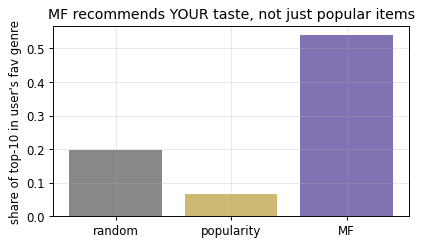

In [10]:
def fav_share(score_fn):
    shares = []
    for u in range(n_users):
        fav = user_pref[u].argmax()
        s = np.asarray(score_fn(u), dtype=float); s[R[u] == 1] = -1e9
        top = np.argsort(-s)[:10]
        shares.append(np.mean(item_genre[top] == fav))
    return np.mean(shares)

mf_share   = fav_share(lambda u: P[u] @ Q.T)
pop_share  = fav_share(lambda u: R.sum(0))
rand_base  = np.mean([np.mean(item_genre == user_pref[u].argmax()) for u in range(n_users)])
print(f"fav-genre share in top-10 — MF {mf_share:.2f}  vs  popularity {pop_share:.2f}  vs  random {rand_base:.2f}")

plt.figure(figsize=(5,3))
plt.bar(["random","popularity","MF"], [rand_base, pop_share, mf_share], color=[GRAY, GOLD, PURPLE])
plt.ylabel("share of top-10 in user's fav genre")
plt.title("MF recommends YOUR taste, not just popular items"); plt.tight_layout(); plt.show()

## 10 · MF top-k — different users, different lists

**Why:** personalization means *different people get different recommendations*. We take
three users with different favorite genres and print each one's MF top-8 (unseen items
only). The lists should lean toward each user's own taste — the whole point of learning a
per-user vector.

In [11]:
# find three users with three different strong favorite genres
picked, seen = [], set()
for u in range(n_users):
    fav = user_pref[u].argmax()
    if user_pref[u, fav] > 0.6 and fav not in seen:
        picked.append(u); seen.add(fav)
    if len(picked) == 3: break

for u in picked:
    pred = P[u] @ Q.T; pred[R[u] == 1] = -np.inf
    recs = np.argsort(-pred)[:8]
    fav = genres[user_pref[u].argmax()]
    share = np.mean(item_genre[recs] == user_pref[u].argmax())
    print(f"user {u:>3} (fav={fav:<8}) top-8 genres: {[genres[item_genre[i]] for i in recs]}  "
          f"[{share:.0%} in fav]")

user   0 (fav=tech    ) top-8 genres: ['tech', 'tech', 'tech', 'tech', 'tech', 'tech', 'tech', 'tech']  [100% in fav]
user   3 (fav=travel  ) top-8 genres: ['travel', 'travel', 'finance', 'tech', 'travel', 'tech', 'tech', 'tech']  [38% in fav]
user   4 (fav=fitness ) top-8 genres: ['finance', 'finance', 'fitness', 'finance', 'fitness', 'travel', 'fitness', 'fitness']  [50% in fav]


---
# Easy (5) — evaluate, compare, and the funnel

## 11 · Proper evaluation — hold out interactions, measure recall@k

**Why:** you can't grade a recommender on data it trained on. We hide one known
interaction per user (leave-one-out), recommend from the rest, and ask: **was the hidden
item in the top-k?** Averaged over users, that's **recall@k** — the standard retrieval
metric. Doing this right is what separates a demo from a result.

In [12]:
def leave_one_out(R, seed=0):
    rng = np.random.default_rng(seed)
    Rtr = R.copy(); test = {}
    for u in range(R.shape[0]):
        items = np.where(R[u] == 1)[0]
        if len(items) < 2: continue
        h = rng.choice(items); Rtr[u, h] = 0; test[u] = h
    return Rtr, test

def recall_at_k(score_fn, Rtr, test, k=10):
    hits = 0
    for u, held in test.items():
        s = np.asarray(score_fn(u, Rtr), dtype=float); s[Rtr[u] == 1] = -np.inf
        if held in np.argsort(-s)[:k]: hits += 1
    return hits/len(test)

Rtr, test = leave_one_out(R)
pop_s = Rtr.sum(0)
print("recall@10 — popularity:", round(recall_at_k(lambda u,Rt: pop_s.copy(), Rtr, test), 3))

recall@10 — popularity: 0.275


## 12 · Bake-off — popularity vs user-CF vs item-CF vs MF

**Why:** put the families on the same held-out test and read recall@10 side by side.
This is the moment the abstract "CF vs MF" becomes a number: personalization should beat
popularity, and MF (which generalizes) should be competitive with or beat neighborhood CF.

{'popularity': 0.275, 'user-CF': 0.67, 'item-CF': 0.745, 'MF': 0.71}


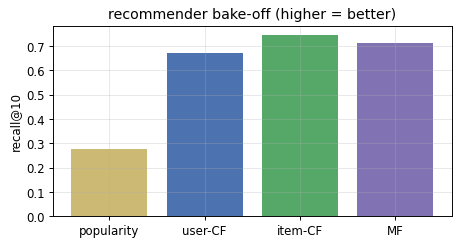

In [13]:
from sklearn.metrics.pairwise import cosine_similarity

def train_mf(Rtr, K=16, epochs=25, lr=0.05, reg=0.02, seed=1):
    rng = np.random.default_rng(seed)
    P = rng.normal(0,0.1,(Rtr.shape[0],K)); Q = rng.normal(0,0.1,(Rtr.shape[1],K))
    pos = np.argwhere(Rtr==1)
    for _ in range(epochs):
        rng.shuffle(pos)
        for u,i in pos:
            j = rng.integers(Rtr.shape[1])
            while Rtr[u,j]==1: j = rng.integers(Rtr.shape[1])
            sig = 1/(1+np.exp(P[u]@(Q[i]-Q[j])))
            P[u]+=lr*(sig*(Q[i]-Q[j])-reg*P[u]); Q[i]+=lr*(sig*P[u]-reg*Q[i]); Q[j]+=lr*(-sig*P[u]-reg*Q[j])
    return P, Q

usim = cosine_similarity(Rtr); np.fill_diagonal(usim,0)
isim = cosine_similarity(Rtr.T); np.fill_diagonal(isim,0)
P,Q = train_mf(Rtr)
scorers = {
  "popularity":  lambda u,Rt: Rt.sum(0).astype(float),
  "user-CF":     lambda u,Rt: usim[u] @ Rt,
  "item-CF":     lambda u,Rt: isim[:, np.where(Rt[u]==1)[0]].sum(1),
  "MF":          lambda u,Rt: P[u] @ Q.T,
}
res = {name: recall_at_k(fn, Rtr, test, 10) for name,fn in scorers.items()}
print({k: round(v,3) for k,v in res.items()})
plt.figure(figsize=(5.5,3)); plt.bar(list(res), list(res.values()), color=[GOLD,BLUE,GREEN,PURPLE])
plt.ylabel("recall@10"); plt.title("recommender bake-off (higher = better)"); plt.tight_layout(); plt.show()

## 13 · The retrieval→ranking funnel

**Why:** you can't run an expensive ranker on a million items per request. The funnel
uses a **cheap** model to retrieve a few hundred candidates, then a **richer** model to
rank just those. We simulate it: MF retrieves top-100, then a "ranker" (here MF score +
a freshness/popularity feature) reorders them. The point is the *shape*, not the ranker.

In [14]:
u = 0
mf_scores = P[u] @ Q.T; mf_scores[Rtr[u]==1] = -np.inf
retrieved = np.argsort(-mf_scores)[:100]                     # cheap retrieval: 120 -> 100
fresh = rng.uniform(0, 0.3, size=n_items)                    # a feature only the ranker sees
rank_score = mf_scores[retrieved] + fresh[retrieved]        # richer ranking on the 100
final = retrieved[np.argsort(-rank_score)][:10]
print("retrieved candidates:", len(retrieved), "-> final slate:", final.tolist())
print("catalog", n_items, "-> retrieve 100 -> rank -> serve 10  (cost scales with candidates, not catalog)")

retrieved candidates: 100 -> final slate: [103, 101, 32, 119, 44, 82, 73, 6, 109, 116]
catalog 120 -> retrieve 100 -> rank -> serve 10  (cost scales with candidates, not catalog)


## 14 · Implicit feedback + negative sampling

**Why:** a "no interaction" is **not** a dislike — the user may never have seen the item.
So we can't treat all zeros as negatives. Instead we **sample** a few negatives per
positive (as MF did in #7). Here we show why the sampling ratio matters: too few
negatives and the model barely learns to separate; more negatives sharpen the ranking.

{1: 0.735, 2: 0.695, 4: 0.63, 8: 0.575}


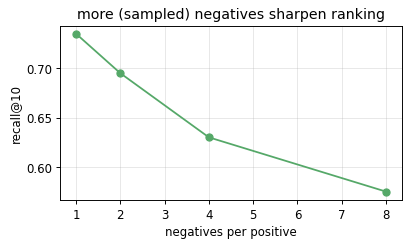

In [15]:
def train_eval(n_neg):
    rng = np.random.default_rng(2)
    P = rng.normal(0,0.1,(n_users,16)); Q = rng.normal(0,0.1,(n_items,16)); pos=np.argwhere(Rtr==1)
    for _ in range(20):
        rng.shuffle(pos)
        for u,i in pos:
            for _ in range(n_neg):
                j = rng.integers(n_items)
                while Rtr[u,j]==1: j=rng.integers(n_items)
                sig = 1/(1+np.exp(P[u]@(Q[i]-Q[j])))
                P[u]+=0.05*(sig*(Q[i]-Q[j])-0.02*P[u]); Q[i]+=0.05*sig*P[u]; Q[j]+=0.05*(-sig*P[u])
    return recall_at_k(lambda u,Rt: P[u]@Q.T, Rtr, test, 10)

ratios = [1,2,4,8]; r = [train_eval(n) for n in ratios]
print(dict(zip(ratios, [round(x,3) for x in r])))
plt.figure(figsize=(5,3)); plt.plot(ratios, r, "o-", color=GREEN)
plt.xlabel("negatives per positive"); plt.ylabel("recall@10"); plt.title("more (sampled) negatives sharpen ranking"); plt.tight_layout(); plt.show()

## 15 · Two-tower retrieval — separate user & item encoders

**Why:** MF learns a vector per *id*; a **two-tower** model learns a function from
**features** to a vector, one tower per side. That's what lets it (a) generalize to new
ids from their features and (b) **precompute all item vectors offline** and only run the
user tower online. We train tiny linear towers (user-genre-pref → embedding, item-genre
one-hot → embedding) with the same BPR objective, then retrieve by dot product.

In [16]:
# features: user = their genre-preference vector; item = one-hot genre + log-popularity
Uf = user_pref.copy()                                        # (200, 5)
If = np.zeros((n_items, n_genres+1)); If[np.arange(n_items), item_genre] = 1
If[:, -1] = np.log1p(item_pop)/np.log1p(item_pop).max()
Wu = rng.normal(0,0.3,(Uf.shape[1],8)); Wi = rng.normal(0,0.3,(If.shape[1],8))  # two towers
pos = np.argwhere(Rtr==1)
for _ in range(40):
    rng.shuffle(pos)
    for u,i in pos:
        j = rng.integers(n_items)
        while Rtr[u,j]==1: j=rng.integers(n_items)
        ue = Uf[u]@Wu; ie, je = If[i]@Wi, If[j]@Wi
        sig = 1/(1+np.exp(ue@(ie-je)))
        Wu += 0.02*np.outer(Uf[u], sig*(ie-je))
        Wi += 0.02*(np.outer(If[i], sig*ue) - np.outer(If[j], sig*ue))
item_emb = If @ Wi                                           # precompute ALL item vectors offline
def tt_score(u, Rt): return (Uf[u]@Wu) @ item_emb.T          # online: one user vector + dot products
print("two-tower recall@10:", round(recall_at_k(tt_score, Rtr, test, 10), 3))
print("item vectors are precomputed once; serving = 1 user-tower pass + a dot-product scan")

two-tower recall@10: 0.77
item vectors are precomputed once; serving = 1 user-tower pass + a dot-product scan


---
# Advanced (5) — ANN, sequence, generative, and cold-start

## 16 · ANN vs brute force — the retrieval speed/recall tradeoff

**Why:** dotting the user against *every* item vector is exact but O(catalog). At scale
you cluster items once (a coarse **inverted index**) and only scan the nearest few
clusters — approximate, but far fewer comparisons. We measure the tradeoff: how much
recall you keep vs how many items you actually scan (nprobe).

 nprobe  recall_vs_brute  avg_items_scanned
      1             0.72              12.70
      2             0.94              28.48
      4             0.93              54.28
      8             1.00             120.00


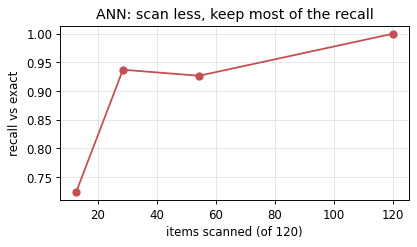

In [17]:
from sklearn.cluster import KMeans
emb = item_emb                                     # from the two-tower
km = KMeans(8, n_init=5, random_state=0).fit(emb)
cluster = km.labels_
def brute(uvec): return np.argsort(-(uvec @ emb.T))[:10]
def ann(uvec, nprobe):
    cdist = uvec @ km.cluster_centers_.T
    keep = np.isin(cluster, np.argsort(-cdist)[:nprobe])
    idx = np.where(keep)[0]
    return idx[np.argsort(-(uvec @ emb[idx].T))[:10]], keep.sum()
rows=[]
for nprobe in [1,2,4,8]:
    ov, scan = [], []
    for u in range(n_users):
        uvec = Uf[u]@Wu; b=set(brute(uvec).tolist()); a,s=ann(uvec,nprobe)
        ov.append(len(b & set(a.tolist()))/10); scan.append(s)
    rows.append((nprobe, np.mean(ov), np.mean(scan)))
tbl = pd.DataFrame(rows, columns=["nprobe","recall_vs_brute","avg_items_scanned"]); print(tbl.round(2).to_string(index=False))
fig,ax=plt.subplots(figsize=(5,3)); ax.plot(tbl.avg_items_scanned, tbl.recall_vs_brute,"o-",color=RED)
ax.set_xlabel("items scanned (of 120)"); ax.set_ylabel("recall vs exact"); ax.set_title("ANN: scan less, keep most of the recall"); plt.tight_layout(); plt.show()

## 17 · Sequential recommendation — when *order* carries intent

**Why:** CF/MF treat a user's history as an unordered **bag**. But `venue → catering →
photographer` implies a next step that the same items shuffled would not. We build a
first-order **Markov** transition matrix over genres from ordered sessions, then run the
**shuffle test**: if predicting the next item from the *last* one beats the bag model,
order carries signal; if shuffling destroys that gain, we've proven it.

next-genre accuracy — ordered: 0.49   shuffled: 0.35


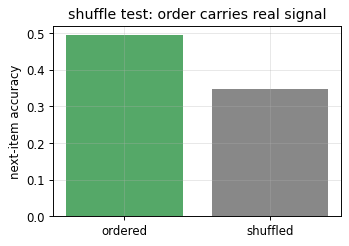

In [18]:
# build ordered sessions where the next genre depends on the current one (real sequential signal)
trans = np.array([[.5,.2,.1,.1,.1],[.1,.5,.2,.1,.1],[.1,.1,.5,.2,.1],[.1,.1,.1,.5,.2],[.2,.1,.1,.1,.5]])
sessions = []
for _ in range(600):
    g = rng.integers(n_genres); seq=[g]
    for _ in range(5): g = rng.choice(n_genres, p=trans[g]); seq.append(g)
    sessions.append(seq)

def next_acc(seqs):
    P = np.ones((n_genres,n_genres))                # learn transitions with add-1 smoothing
    for s in seqs:
        for a,b in zip(s[:-1], s[1:]): P[a,b]+=1
    P /= P.sum(1,keepdims=True)
    hits=tot=0
    for s in seqs:
        for a,b in zip(s[:-1], s[1:]):
            if P[a].argmax()==b: hits+=1
            tot+=1
    return hits/tot

ordered = next_acc(sessions)
shuffled = next_acc([list(rng.permutation(s)) for s in sessions])
print(f"next-genre accuracy — ordered: {ordered:.2f}   shuffled: {shuffled:.2f}")
plt.figure(figsize=(4.2,3)); plt.bar(["ordered","shuffled"], [ordered, shuffled], color=[GREEN, GRAY])
plt.ylabel("next-item accuracy"); plt.title("shuffle test: order carries real signal"); plt.tight_layout(); plt.show()

## 18 · Generative retrieval — items as *semantic ID codes*

**Why:** generative recommenders (TIGER/HSTU) replace "search nearest vector" with
"**generate the item's code**." The trick is giving each item a short discrete **semantic
ID** so similar items share a prefix. We build 2-level codes by clustering item vectors
twice (a mini RQ-VAE): code = (coarse cluster, fine cluster). Then "generating" a coarse
code retrieves a whole semantic group — retrieval by generation, and prefixes give free
diversity/'control'.

example semantic IDs:
  item   genre  code
    0    tech (4,0)
    1  travel (0,3)
    2  travel (0,1)
    3 fitness (2,2)
    4 fitness (2,2)
    5 finance (3,0)
    6    tech (4,2)
    7  travel (5,3)

generating coarse code 4 retrieves items: [0, 6, 9, 17, 22, 32, 35, 40] | dominant genre: tech


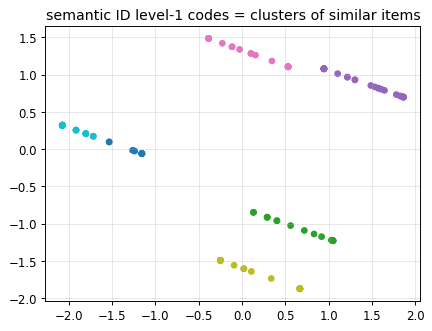

In [19]:
from sklearn.cluster import KMeans
c1 = KMeans(6, n_init=5, random_state=0).fit(item_emb)
codebook1 = c1.labels_
resid = item_emb - c1.cluster_centers_[codebook1]           # residual quantization
c2 = KMeans(4, n_init=5, random_state=1).fit(resid)
codebook2 = c2.labels_
codes = pd.DataFrame({"item":range(n_items), "genre":[genres[g] for g in item_genre],
                      "code":[f"({a},{b})" for a,b in zip(codebook1, codebook2)]})
print("example semantic IDs:\n", codes.head(8).to_string(index=False))
# "generate" a coarse code -> retrieve its items
g0 = codebook1[0]
print(f"\ngenerating coarse code {g0} retrieves items:",
      np.where(codebook1==g0)[0][:8].tolist(),
      "| dominant genre:", codes[codebook1==g0].genre.mode()[0])
plt.figure(figsize=(5.2,4))
plt.scatter(*PCA(2).fit_transform(item_emb).T, c=codebook1, cmap="tab10", s=22)
plt.title("semantic ID level-1 codes = clusters of similar items"); plt.tight_layout(); plt.show()

## 19 · Full funnel bake-off — all families, one recall@10 chart

**Why:** the closing picture. Every family on the same held-out test, so the "pick per
use-case" decision is grounded in numbers, not vibes. Popularity is the floor;
personalization (CF/MF/two-tower) should clear it.

{'popularity': 0.275, 'user-CF': 0.67, 'item-CF': 0.745, 'MF': 0.71, 'two-tower': 0.77}


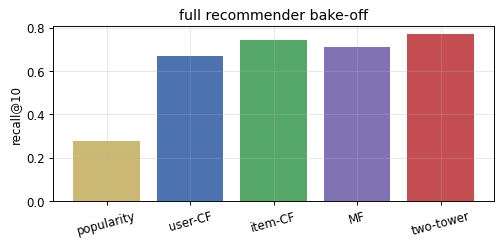

In [20]:
allres = dict(res)                                          # popularity, user-CF, item-CF, MF from #12
allres["two-tower"] = recall_at_k(tt_score, Rtr, test, 10)
print({k: round(v,3) for k,v in allres.items()})
plt.figure(figsize=(6,3))
plt.bar(list(allres), list(allres.values()), color=[GOLD,BLUE,GREEN,PURPLE,RED])
plt.ylabel("recall@10"); plt.title("full recommender bake-off"); plt.xticks(rotation=15); plt.tight_layout(); plt.show()

## 20 · Cold-start, solved — content features rescue the new item

**Why:** #6 showed CF is blind to a new item. The fix: represent items by **content**
(here their genre features), so a brand-new item inherits a vector from its metadata and
can be scored immediately — no interactions required. This is why hybrid/content models
own the cold-start regime.

In [21]:
new_feat = np.zeros(n_genres+1); new_feat[2] = 1; new_feat[-1] = 0.0   # a new *fitness* item, 0 popularity
new_item_emb = new_feat @ Wi                                # content tower gives it a vector instantly
fitness_fans = [u for u in range(n_users) if user_pref[u,2] > 0.2]
scores = np.array([(Uf[u]@Wu) @ new_item_emb for u in range(n_users)])
top_users = np.argsort(-scores)[:10]
frac = np.mean([user_pref[u,2] > 0.2 for u in top_users])
print(f"new fitness item (0 interactions) is matched to users; "
      f"{frac:.0%} of its top-10 users are fitness fans")
print("CF scored it 0 everywhere (#6); the content tower places it correctly on day one.")

new fitness item (0 interactions) is matched to users; 100% of its top-10 users are fitness fans
CF scored it 0 everywhere (#6); the content tower places it correctly on day one.


---
## Recap — picking a family

- **Popularity:** the floor. Always compute it; be suspicious of models that don't beat it.
- **Neighborhood CF (user/item):** "similar users/items"; explainable, but **sparse &
  cold-start-blind** (all-zero rows/columns have no neighbors).
- **Matrix factorization:** latent factors via dot product; **generalizes past exact
  overlaps**, still needs interactions per id.
- **Two-tower:** learns *feature→vector* towers; **precompute item vectors, retrieve with
  ANN**; handles new ids from features.
- **Sequential:** when **order** changes intent (pass the shuffle test first).
- **Generative:** items as **semantic ID codes**, retrieval-by-generation; powerful but
  needs validity/diversity/serving controls.
- **Cold-start:** add **content/hybrid** features so new items get a vector on day one.

Rule of thumb: **retrieve cheap (CF/MF/two-tower) → rank rich**; add **sequence** only
when order pays for itself; reach for **generative** as a sequence-native research path.